# Expected Loss Calculation

**Formula:** `EL = cum_pd_logit × LGD × ead_proxy`

- `cum_pd_logit`: 12-month cumulative PD from the logistic hazard model
- `LGD`: Loss Given Default = **0.9154** (fixed assumption; will be replaced by an LGD model in the next step)
- `ead_proxy`: Exposure at Default (currently equals `loan_amnt`)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

# Load data
df = pd.read_csv("loan_level_12m_outputs.csv")
print(f"Loaded {len(df):,} loans")
print(f"Required columns: cum_pd_logit, ead_proxy, loan_amnt, issue_d")
df[["id", "issue_d", "loan_amnt", "cum_pd_logit", "ead_proxy"]].head()

Loaded 17,202 loans
Required columns: cum_pd_logit, ead_proxy, loan_amnt, issue_d


,id,issue_d,loan_amnt,cum_pd_logit,ead_proxy
0,100001365,2017-03-01,"20,000.0000",0.0707,"20,000.0000"
1,100001532,2017-03-01,"30,000.0000",0.0242,"30,000.0000"
2,100001557,2017-03-01,"28,000.0000",0.0668,"28,000.0000"
3,100002096,2017-03-01,"20,000.0000",0.0609,"20,000.0000"
4,100002651,2017-03-01,"10,000.0000",0.0967,"10,000.0000"


In [ ]:
# Calculate Expected Loss per loan
# expected_loss = PD x LGD x EAD

LGD = 0.9154  

df["lgd"] = LGD
df["expected_loss"] = df["cum_pd_logit"] * df["lgd"] * df["ead_proxy"]

# Summary
print(f"LGD applied: {LGD}")
print(f"\nexpected_loss column added to dataframe.")
print(f"\nexpected_loss statistics:")
print(df["expected_loss"].describe().round(2))
print(f"\nTotal expected_loss: ${df['expected_loss'].sum():,.2f}")
print(f"Total Loan Amount:   ${df['loan_amnt'].sum():,.2f}")
print(
    f"Portfolio EL rate:   {df['expected_loss'].sum() / df['loan_amnt'].sum() * 100:.2f}%"
)

LGD applied: 0.9154

expected_loss column added to dataframe.

expected_loss statistics:
count   17,202.0000
mean       825.6700
std      1,032.8200
min          0.0000
25%        263.1800
50%        544.7700
75%      1,063.8500
max     32,039.0000
Name: expected_loss, dtype: float64

Total expected_loss: $14,203,197.05
Total Loan Amount:   $260,868,450.00
Portfolio EL rate:   5.44%


In [3]:
# Per-loan expected_loss - show the first 10 loans
# Each row shows one loan's individual expected_loss value
df[
    ["id", "issue_d", "loan_amnt", "cum_pd_logit", "lgd", "ead_proxy", "expected_loss"]
].head(10)

,id,issue_d,loan_amnt,cum_pd_logit,lgd,ead_proxy,expected_loss
0,100001365,2017-03-01,"20,000.0000",0.0707,0.9154,"20,000.0000","1,293.8942"
1,100001532,2017-03-01,"30,000.0000",0.0242,0.9154,"30,000.0000",664.6779
2,100001557,2017-03-01,"28,000.0000",0.0668,0.9154,"28,000.0000","1,711.5223"
3,100002096,2017-03-01,"20,000.0000",0.0609,0.9154,"20,000.0000","1,115.6027"
4,100002651,2017-03-01,"10,000.0000",0.0967,0.9154,"10,000.0000",885.6322
5,100003354,2017-03-01,"4,000.0000",0.0648,0.9154,"4,000.0000",237.2979
6,100003912,2017-03-01,"28,500.0000",0.0445,0.9154,"28,500.0000","1,160.7181"
7,100005538,2017-03-01,"14,400.0000",0.0702,0.9154,"14,400.0000",924.9606
8,100005957,2017-03-01,"16,000.0000",0.0542,0.9154,"16,000.0000",794.3941
9,100006185,2017-03-01,"33,000.0000",0.0481,0.9154,"33,000.0000","1,454.0826"


In [ ]:
# Aggregate expected_loss by risk band

band_summary = (
    df.groupby("risk_band_logit", observed=True)
    .agg(
        n_loans=("id", "count"),
        total_loan_amt=("loan_amnt", "sum"),
        avg_pd=("cum_pd_logit", "mean"),
        total_expected_loss=("expected_loss", "sum"),
    )
    .round(2)
)

# Order bands from Very Low to Very High
band_order = ["Very Low", "Low", "Medium", "High", "Very High"]
band_summary = band_summary.reindex(band_order)

# Add EL rate column
band_summary["el_rate_%"] = (
    band_summary["total_expected_loss"] / band_summary["total_loan_amt"] * 100
).round(2)

print("Expected Loss by Risk Band:")
band_summary

Expected Loss by Risk Band:


,n_loans,total_loan_amt,avg_pd,total_expected_loss,el_rate_%
risk_band_logit,,,,,
Very Low,3441,"48,241,750.0000",0.0200,"924,994.4100",1.9200
Low,3440,"48,031,250.0000",0.0400,"1,591,861.9700",3.3100
Medium,3440,"49,883,375.0000",0.0500,"2,222,523.8600",4.4600
High,3440,"52,322,800.0000",0.0600,"3,090,053.5900",5.9100
Very High,3441,"62,389,275.0000",0.1100,"6,373,763.2200",10.2200


In [ ]:
# Aggregate expected_loss by vintage (issue quarter)

df["issue_d"] = pd.to_datetime(df["issue_d"])
df["issue_quarter"] = df["issue_d"].dt.to_period("Q").astype(str)

vintage_summary = (
    df.groupby("issue_quarter")
    .agg(
        n_loans=("id", "count"),
        total_loan_amt=("loan_amnt", "sum"),
        avg_pd_12m=("cum_pd_logit", "mean"),
        total_expected_loss=("expected_loss", "sum"),
    )
    .round(2)
)

vintage_summary["el_rate_%"] = (
    vintage_summary["total_expected_loss"] / vintage_summary["total_loan_amt"] * 100
).round(2)

print("Expected Loss by Vintage:")
vintage_summary

Expected Loss by Vintage:


,n_loans,total_loan_amt,avg_pd_12m,total_expected_loss,el_rate_%
issue_quarter,,,,,
2017Q1,3084,"45,540,075.0000",0.0600,"2,411,398.7400",5.3000
2017Q2,3270,"47,480,725.0000",0.0600,"2,550,681.9600",5.3700
2017Q3,3797,"55,709,925.0000",0.0600,"3,260,902.2500",5.8500
2017Q4,3692,"57,057,450.0000",0.0500,"3,082,134.4300",5.4000
2018Q1,3359,"55,080,275.0000",0.0500,"2,898,079.6700",5.2600


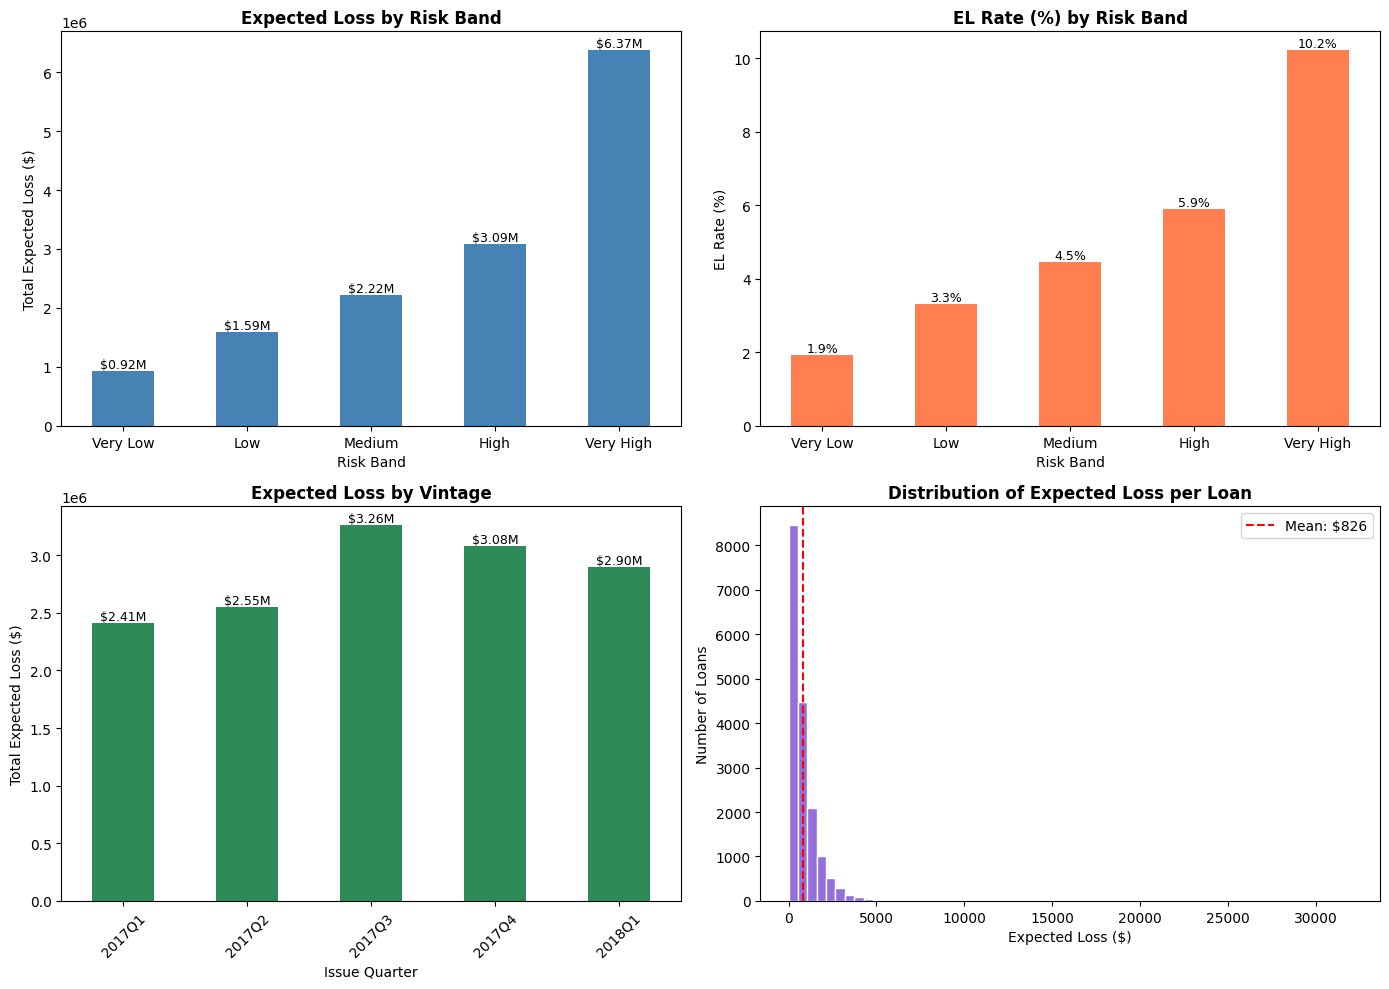

In [ ]:
 # Visualizations

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: EL by risk band
ax = axes[0, 0]
band_summary_plot = band_summary.dropna()
band_summary_plot["total_expected_loss"].plot(kind="bar", ax=ax, color="steelblue")
ax.set_title("Expected Loss by Risk Band", fontsize=12, fontweight="bold")
ax.set_ylabel("Total Expected Loss ($)")
ax.set_xlabel("Risk Band")
ax.tick_params(axis="x", rotation=0)
for i, v in enumerate(band_summary_plot["total_expected_loss"]):
    ax.text(i, v, f"${v/1e6:.2f}M", ha="center", va="bottom", fontsize=9)

# Plot 2: EL rate by risk band
ax = axes[0, 1]
band_summary_plot["el_rate_%"].plot(kind="bar", ax=ax, color="coral")
ax.set_title("EL Rate (%) by Risk Band", fontsize=12, fontweight="bold")
ax.set_ylabel("EL Rate (%)")
ax.set_xlabel("Risk Band")
ax.tick_params(axis="x", rotation=0)
for i, v in enumerate(band_summary_plot["el_rate_%"]):
    ax.text(i, v, f"{v:.1f}%", ha="center", va="bottom", fontsize=9)

# Plot 3: EL by vintage
ax = axes[1, 0]
vintage_summary["total_expected_loss"].plot(kind="bar", ax=ax, color="seagreen")
ax.set_title("Expected Loss by Vintage", fontsize=12, fontweight="bold")
ax.set_ylabel("Total Expected Loss ($)")
ax.set_xlabel("Issue Quarter")
ax.tick_params(axis="x", rotation=45)
for i, v in enumerate(vintage_summary["total_expected_loss"]):
    ax.text(i, v, f"${v/1e6:.2f}M", ha="center", va="bottom", fontsize=9)

# Plot 4: Distribution of expected_loss per loan
ax = axes[1, 1]
ax.hist(df["expected_loss"], bins=60, color="mediumpurple", edgecolor="white")
ax.set_title("Distribution of Expected Loss per Loan", fontsize=12, fontweight="bold")
ax.set_xlabel("Expected Loss ($)")
ax.set_ylabel("Number of Loans")
ax.axvline(
    df["expected_loss"].mean(),
    color="red",
    linestyle="--",
    label=f"Mean: ${df['expected_loss'].mean():,.0f}",
)
ax.legend()

plt.tight_layout()
plt.savefig("expected_loss_overview.png", dpi=100, bbox_inches="tight")
plt.show()

In [ ]:

# Save outputs

# Save loan-level output (key columns only, including expected_loss column)
output_cols = [
    "id",
    "issue_d",
    "issue_quarter",
    "loan_amnt",
    "cum_pd_logit",
    "lgd",
    "ead_proxy",
    "expected_loss",
    "risk_band_logit",
]
df[output_cols].to_csv("loan_level_el.csv", index=False)

# Save vintage summary
vintage_summary.to_csv("vintage_el_summary.csv")

# Save risk band summary
band_summary.to_csv("risk_band_el_summary.csv")

print("Saved:")
print("  - loan_level_el.csv         (per-loan expected_loss)")
print("  - vintage_el_summary.csv    (aggregated by issue quarter)")
print("  - risk_band_el_summary.csv  (aggregated by risk band)")
print("  - expected_loss_overview.png (four-panel summary chart)")

Saved:
  - loan_level_el.csv         (per-loan expected_loss)
  - vintage_el_summary.csv    (aggregated by issue quarter)
  - risk_band_el_summary.csv  (aggregated by risk band)
  - expected_loss_overview.png (four-panel summary chart)
